In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:

# ==========================================
# 1. خواندن داده
# ==========================================

data = pd.read_csv("E:/pro/uni_project/adjusted_dataset_mlALL.csv")
df = data.copy()

df = df.dropna()

In [5]:
def directional_accuracy(actual, predicted, previous):

    actual_change = actual - previous
    predicted_change = predicted - previous

    valid = actual_change != 0

    actual_direction = np.sign(
        actual_change[valid]
    )

    predicted_direction = np.sign(
        predicted_change[valid]
    )

    return (
        np.mean(
            actual_direction ==
            predicted_direction
        ) * 100
    )

In [3]:
# ============================================================
# FINAL FEATURE ENGINEERING FOR LSTM
# Foolad - Next Day Return Prediction
# ============================================================

import numpy as np
import pandas as pd
import pywt

# ============================================================
# 1. BASIC PREPARATION
# ============================================================

df = df.copy().sort_index()

# قیمت‌های تعدیل‌شده
df["CLOSE"] = df["adj_close"]
df["OPEN"]  = df["adj_open"]
df["HIGH"]  = df["adj_high"]
df["LOW"]   = df["adj_low"]

df["VOLUME"] = df["VOL"]

# حذف inf اولیه
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 2. LOG RETURN
# ============================================================

df["LOG_RETURN"] = np.log(
    df["CLOSE"] /
    df["CLOSE"].shift(1)
)


# ============================================================
# 3. BASIC PRICE / CANDLE FEATURES
# ============================================================

df["HIGH_LOW_PCT"] = (
    (df["HIGH"] - df["LOW"])
    / df["CLOSE"]
)

df["OPEN_CLOSE_PCT"] = (
    (df["CLOSE"] - df["OPEN"])
    / df["OPEN"]
)

df["BODY_SIZE"] = (
    abs(df["CLOSE"] - df["OPEN"])
    / df["CLOSE"]
)

df["UPPER_SHADOW"] = (
    df["HIGH"]
    - np.maximum(
        df["OPEN"],
        df["CLOSE"]
    )
) / df["CLOSE"]

df["LOWER_SHADOW"] = (
    np.minimum(
        df["OPEN"],
        df["CLOSE"]
    )
    - df["LOW"]
) / df["CLOSE"]


# ============================================================
# 4. RETURNS
# ============================================================

for period in [1, 2, 3, 5, 10, 20]:

    df[f"RETURN_{period}"] = (
        df["CLOSE"].pct_change(period)
    )


# ============================================================
# 5. MOMENTUM
# ============================================================

df["ROC_3"] = (
    df["CLOSE"].pct_change(3)
)

df["ROC_5"] = (
    df["CLOSE"].pct_change(5)
)

df["ROC_10"] = (
    df["CLOSE"].pct_change(10)
)

df["MOMENTUM_5"] = (
    df["CLOSE"]
    / df["CLOSE"].shift(5)
    - 1
)

df["MOMENTUM_10"] = (
    df["CLOSE"]
    / df["CLOSE"].shift(10)
    - 1
)


# ============================================================
# 6. MOVING AVERAGES
# ============================================================

for period in [5, 10, 20, 60]:

    df[f"MA_{period}"] = (
        df["CLOSE"]
        .rolling(period)
        .mean()
    )

    df[f"MA_DISTANCE_{period}"] = (
        df["CLOSE"]
        / df[f"MA_{period}"]
        - 1
    )


# MA slopes

df["MA5_SLOPE"] = (
    df["MA_5"].pct_change()
)

df["MA10_SLOPE"] = (
    df["MA_10"].pct_change()
)

df["MA20_SLOPE"] = (
    df["MA_20"].pct_change()
)


# ============================================================
# 7. EMA
# ============================================================

df["EMA_12"] = (
    df["CLOSE"]
    .ewm(
        span=12,
        adjust=False
    )
    .mean()
)

df["EMA_26"] = (
    df["CLOSE"]
    .ewm(
        span=26,
        adjust=False
    )
    .mean()
)

df["EMA12_DISTANCE"] = (
    df["CLOSE"]
    / df["EMA_12"]
    - 1
)

df["EMA26_DISTANCE"] = (
    df["CLOSE"]
    / df["EMA_26"]
    - 1
)


# ============================================================
# 8. VOLATILITY
# ============================================================

for period in [5, 10, 20, 60]:

    df[f"STD_{period}"] = (
        df["LOG_RETURN"]
        .rolling(period)
        .std()
    )


df["REALIZED_VOLATILITY"] = (
    df["LOG_RETURN"]
    .rolling(20)
    .std()
    * np.sqrt(20)
)


# ============================================================
# 9. RSI
# ============================================================

delta = df["CLOSE"].diff()

gain = delta.clip(
    lower=0
)

loss = -delta.clip(
    upper=0
)

avg_gain = (
    gain
    .rolling(14)
    .mean()
)

avg_loss = (
    loss
    .rolling(14)
    .mean()
)

rs = (
    avg_gain
    /
    (avg_loss + 1e-8)
)

df["RSI_14"] = (
    100 -
    (
        100 /
        (1 + rs)
    )
)

df["RSI_CHANGE"] = (
    df["RSI_14"].diff()
)

# RSI distance from neutral point

df["RSI_DISTANCE"] = (
    df["RSI_14"] - 50
)


# ============================================================
# 10. MACD
# ============================================================

df["MACD"] = (
    df["EMA_12"]
    -
    df["EMA_26"]
)

df["MACD_SIGNAL"] = (
    df["MACD"]
    .ewm(
        span=9,
        adjust=False
    )
    .mean()
)

df["MACD_HIST"] = (
    df["MACD"]
    -
    df["MACD_SIGNAL"]
)


# ============================================================
# 11. BOLLINGER BANDS
# ============================================================

bb_mean = (
    df["CLOSE"]
    .rolling(20)
    .mean()
)

bb_std = (
    df["CLOSE"]
    .rolling(20)
    .std()
)

df["BB_UPPER"] = (
    bb_mean
    + 2 * bb_std
)

df["BB_LOWER"] = (
    bb_mean
    - 2 * bb_std
)

df["BB_WIDTH"] = (
    df["BB_UPPER"]
    -
    df["BB_LOWER"]
) / bb_mean

df["BB_POSITION"] = (
    df["CLOSE"]
    -
    df["BB_LOWER"]
) / (
    df["BB_UPPER"]
    -
    df["BB_LOWER"]
    + 1e-8
)


# ============================================================
# 12. ATR
# ============================================================

previous_close = (
    df["CLOSE"].shift(1)
)

TR1 = (
    df["HIGH"]
    -
    df["LOW"]
)

TR2 = abs(
    df["HIGH"]
    -
    previous_close
)

TR3 = abs(
    df["LOW"]
    -
    previous_close
)

true_range = pd.concat(
    [TR1, TR2, TR3],
    axis=1
).max(axis=1)

df["ATR_14"] = (
    true_range
    .rolling(14)
    .mean()
)

df["ATR_14_PCT"] = (
    df["ATR_14"]
    /
    df["CLOSE"]
)


# ============================================================
# 13. STOCHASTIC
# ============================================================

lowest_14 = (
    df["LOW"]
    .rolling(14)
    .min()
)

highest_14 = (
    df["HIGH"]
    .rolling(14)
    .max()
)

df["STOCH_K"] = (
    100 *
    (
        df["CLOSE"]
        -
        lowest_14
    )
    /
    (
        highest_14
        -
        lowest_14
        + 1e-8
    )
)

df["STOCH_D"] = (
    df["STOCH_K"]
    .rolling(3)
    .mean()
)


# ============================================================
# 14. VOLUME FEATURES
# ============================================================

df["VOL_MA_5"] = (
    df["VOLUME"]
    .rolling(5)
    .mean()
)

df["VOL_MA_10"] = (
    df["VOLUME"]
    .rolling(10)
    .mean()
)

df["VOL_MA_20"] = (
    df["VOLUME"]
    .rolling(20)
    .mean()
)

df["VOLUME_RATIO"] = (
    df["VOLUME"]
    /
    (df["VOL_MA_20"] + 1e-8)
)

df["VOLUME_CHANGE"] = (
    df["VOLUME"]
    .pct_change()
)

df["VOL_MA_RATIO_5_20"] = (
    df["VOL_MA_5"]
    /
    (df["VOL_MA_20"] + 1e-8)
)


# ============================================================
# 15. RETURN DISTRIBUTION
# ============================================================

df["RETURN_STD_5"] = (
    df["LOG_RETURN"]
    .rolling(5)
    .std()
)

df["RETURN_STD_10"] = (
    df["LOG_RETURN"]
    .rolling(10)
    .std()
)

df["RETURN_SKEW_10"] = (
    df["LOG_RETURN"]
    .rolling(10)
    .skew()
)


# ============================================================
# 16. WAVELET DENOISING
# ============================================================

def wavelet_denoise(
    series,
    wavelet="db4",
    level=2
):

    x = series.fillna(0).values.astype(float)

    coeffs = pywt.wavedec(
        x,
        wavelet,
        mode="symmetric",
        level=level
    )

    sigma = (
        np.median(
            np.abs(coeffs[-1])
        )
        / 0.6745
    )

    threshold = (
        sigma *
        np.sqrt(
            2 * np.log(len(x))
        )
    )

    filtered_coeffs = [
        coeffs[0]
    ]

    for coeff in coeffs[1:]:

        filtered_coeffs.append(
            pywt.threshold(
                coeff,
                threshold,
                mode="soft"
            )
        )

    reconstructed = (
        pywt.waverec(
            filtered_coeffs,
            wavelet,
            mode="symmetric"
        )
    )

    return reconstructed[
        :len(x)
    ]


df["WAVELET_RETURN"] = (
    wavelet_denoise(
        df["LOG_RETURN"]
    )
)

df["WAVELET_MOMENTUM"] = (
    df["WAVELET_RETURN"]
    .rolling(5)
    .mean()
)

df["WAVELET_VOLATILITY"] = (
    df["WAVELET_RETURN"]
    .rolling(10)
    .std()
)


# ============================================================
# 17. TARGET
# ============================================================

# هدف = بازده لگاریتمی روز بعد

df["TARGET_RETURN"] = (
    np.log(
        df["CLOSE"].shift(-1)
        /
        df["CLOSE"]
    )
)


# ============================================================
# 18. FINAL FEATURES
# ============================================================

features_engineered = [

    # Candle
    "HIGH_LOW_PCT",
    "OPEN_CLOSE_PCT",
    "BODY_SIZE",
    "UPPER_SHADOW",
    "LOWER_SHADOW",

    # Returns
    "RETURN_1",
    "RETURN_2",
    "RETURN_3",
    "RETURN_5",
    "RETURN_10",
    "RETURN_20",

    # Momentum
    "ROC_3",
    "ROC_5",
    "ROC_10",
    "MOMENTUM_5",
    "MOMENTUM_10",

    # MA
    "MA_DISTANCE_5",
    "MA_DISTANCE_10",
    "MA_DISTANCE_20",
    "MA_DISTANCE_60",

    "MA5_SLOPE",
    "MA10_SLOPE",
    "MA20_SLOPE",

    # EMA
    "EMA12_DISTANCE",
    "EMA26_DISTANCE",

    # Volatility
    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",

    "REALIZED_VOLATILITY",

    # RSI
    "RSI_14",
    "RSI_CHANGE",
    "RSI_DISTANCE",

    # MACD
    "MACD",
    "MACD_SIGNAL",
    "MACD_HIST",

    # Bollinger
    "BB_WIDTH",
    "BB_POSITION",

    # ATR
    "ATR_14_PCT",

    # Stochastic
    "STOCH_K",
    "STOCH_D",

    # Volume
    "VOLUME_RATIO",
    "VOLUME_CHANGE",
    "VOL_MA_RATIO_5_20",

    # Distribution
    "RETURN_STD_5",
    "RETURN_STD_10",
    "RETURN_SKEW_10",

    # Wavelet
    "WAVELET_RETURN",
    "WAVELET_MOMENTUM",
    "WAVELET_VOLATILITY"
]


# ============================================================
# 19. FINAL DATASET
# ============================================================

model_df = df[
    features_engineered
    +
    [
        "TARGET_RETURN",
        "CLOSE"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


# ============================================================
# 20. CHRONOLOGICAL SPLIT
# ============================================================

split_index = int(
    len(model_df) * 0.80
)

train_df = (
    model_df
    .iloc[:split_index]
    .copy()
)

test_df = (
    model_df
    .iloc[split_index:]
    .copy()
)


X_train = train_df[
    features_engineered
]

y_train = train_df[
    "TARGET_RETURN"
]

X_test = test_df[
    features_engineered
]

y_test = test_df[
    "TARGET_RETURN"
]


# ============================================================
# 21. INFORMATION
# ============================================================

print("=" * 65)
print("FINAL LSTM FEATURE ENGINEERING")
print("=" * 65)

print(
    "Rows:",
    len(model_df)
)

print(
    "Features:",
    len(features_engineered)
)

print(
    "Train:",
    X_train.shape
)

print(
    "Test:",
    X_test.shape
)

print(
    "\nTARGET = NEXT-DAY LOG RETURN"
)

print("\nFEATURES:")

for i, feature in enumerate(
    features_engineered,
    1
):

    print(
        f"{i:2d}. {feature}"
    )

print("=" * 65)

FINAL LSTM FEATURE ENGINEERING
Rows: 4136
Features: 50
Train: (3308, 50)
Test: (828, 50)

TARGET = NEXT-DAY LOG RETURN

FEATURES:
 1. HIGH_LOW_PCT
 2. OPEN_CLOSE_PCT
 3. BODY_SIZE
 4. UPPER_SHADOW
 5. LOWER_SHADOW
 6. RETURN_1
 7. RETURN_2
 8. RETURN_3
 9. RETURN_5
10. RETURN_10
11. RETURN_20
12. ROC_3
13. ROC_5
14. ROC_10
15. MOMENTUM_5
16. MOMENTUM_10
17. MA_DISTANCE_5
18. MA_DISTANCE_10
19. MA_DISTANCE_20
20. MA_DISTANCE_60
21. MA5_SLOPE
22. MA10_SLOPE
23. MA20_SLOPE
24. EMA12_DISTANCE
25. EMA26_DISTANCE
26. STD_5
27. STD_10
28. STD_20
29. STD_60
30. REALIZED_VOLATILITY
31. RSI_14
32. RSI_CHANGE
33. RSI_DISTANCE
34. MACD
35. MACD_SIGNAL
36. MACD_HIST
37. BB_WIDTH
38. BB_POSITION
39. ATR_14_PCT
40. STOCH_K
41. STOCH_D
42. VOLUME_RATIO
43. VOLUME_CHANGE
44. VOL_MA_RATIO_5_20
45. RETURN_STD_5
46. RETURN_STD_10
47. RETURN_SKEW_10
48. WAVELET_RETURN
49. WAVELET_MOMENTUM
50. WAVELET_VOLATILITY


In [4]:
# ============================================================
# 22. SCALING
# ============================================================

from sklearn.preprocessing import RobustScaler

scaler_X = RobustScaler()
scaler_y = RobustScaler()


X_train_scaled = (
    scaler_X
    .fit_transform(X_train)
)

X_test_scaled = (
    scaler_X
    .transform(X_test)
)


y_train_scaled = (
    scaler_y
    .fit_transform(
        y_train.values.reshape(-1, 1)
    )
    .flatten()
)

y_test_scaled = (
    scaler_y
    .transform(
        y_test.values.reshape(-1, 1)
    )
    .flatten()
)


# ============================================================
# 23. SEQUENCE
# ============================================================

TIME_STEPS = 10


def create_sequences(
    X,
    y,
    time_steps
):

    X_seq = []
    y_seq = []

    for i in range(
        time_steps,
        len(X)
    ):

        X_seq.append(
            X[
                i-time_steps:i
            ]
        )

        y_seq.append(
            y[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )


X_train_seq, y_train_seq = (
    create_sequences(
        X_train_scaled,
        y_train_scaled,
        TIME_STEPS
    )
)


X_test_seq, y_test_seq = (
    create_sequences(
        X_test_scaled,
        y_test_scaled,
        TIME_STEPS
    )
)


print("\nSequence shapes:")

print(
    "X_train:",
    X_train_seq.shape
)

print(
    "y_train:",
    y_train_seq.shape
)

print(
    "X_test:",
    X_test_seq.shape
)

print(
    "y_test:",
    y_test_seq.shape
)


Sequence shapes:
X_train: (3298, 10, 50)
y_train: (3298,)
X_test: (818, 10, 50)
y_test: (818,)


DATASET
Rows: 4136
Features: 46

Direction distribution:
TARGET_DIRECTION
0    0.536267
1    0.463733
Name: proportion, dtype: float64


Running: V2_A

Validation SMAPE : 2.2554%
Best Threshold   : 0.48
Direction Acc.   : 54.66%
Balanced Acc.    : 55.23%
Combined Score   : 4.2048


Running: V2_B
Validation SMAPE : 2.2182%
Best Threshold   : 0.54
Direction Acc.   : 54.25%
Balanced Acc.    : 52.37%
Combined Score   : 3.8074


Running: V2_C
Validation SMAPE : 2.2500%
Best Threshold   : 0.50
Direction Acc.   : 55.47%
Balanced Acc.    : 55.01%
Combined Score   : 5.0156


Running: V2_D
Validation SMAPE : 2.2687%
Best Threshold   : 0.57
Direction Acc.   : 54.05%
Balanced Acc.    : 51.02%
Combined Score   : 3.5948


Running: V2_E
Validation SMAPE : 2.2640%
Best Threshold   : 0.48
Direction Acc.   : 53.85%
Balanced Acc.    : 52.91%
Combined Score   : 3.3933


VALIDATION RESULTS
Model  Val_SMAPE  Threshold  Direction_Accuracy  Balanced_Accuracy  Combined_Score
 V2_C   2.250037       0.50        

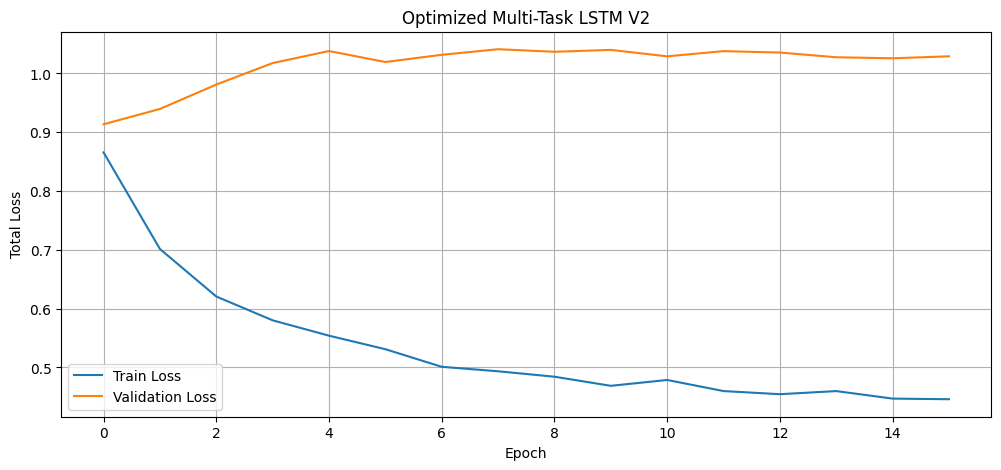

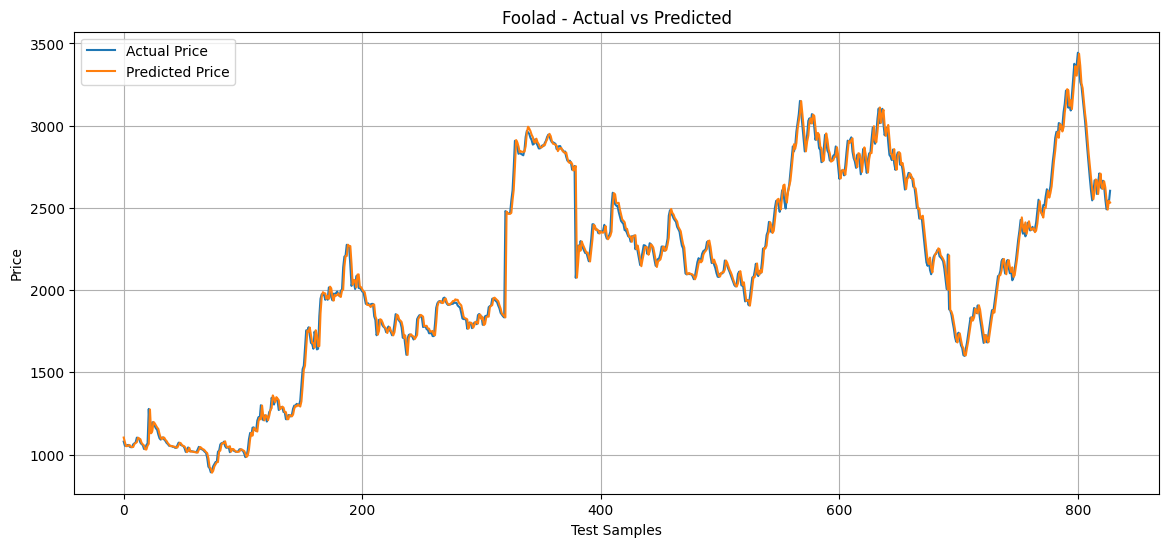

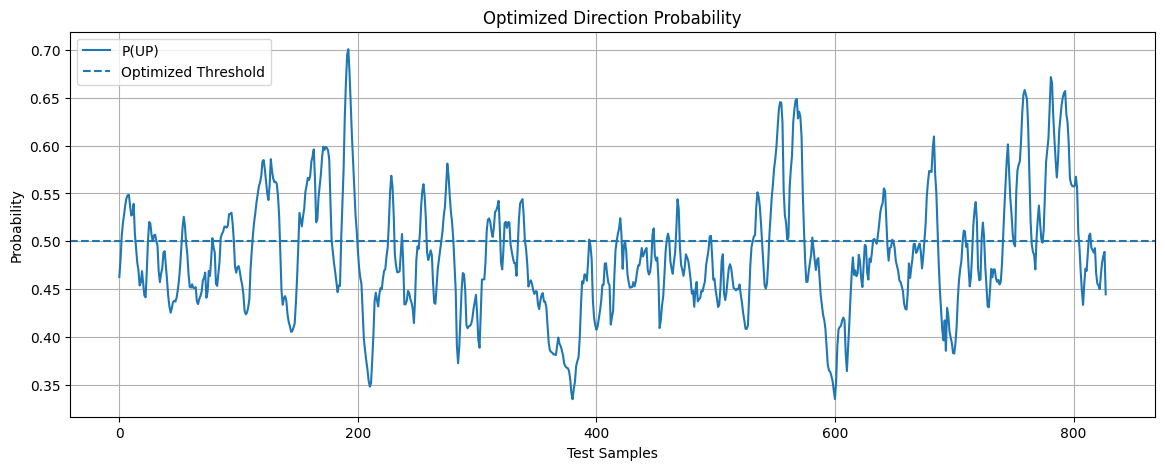

In [6]:
# ============================================================
# MULTI-TASK LSTM V2
# Goal:
#   1) Keep price error low
#   2) Increase Direction Accuracy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.losses import Huber


# ============================================================
# 1. SEED
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 2. DATA
# ============================================================

data = df.copy().sort_index()

data["CLOSE"] = data["adj_close"]
data["OPEN"] = data["adj_open"]
data["HIGH"] = data["adj_high"]
data["LOW"] = data["adj_low"]

data["VOLUME"] = data["VOL"]


# ============================================================
# 3. LOG RETURN
# ============================================================

data["LOG_RETURN"] = np.log(
    data["CLOSE"] /
    data["CLOSE"].shift(1)
)


# ============================================================
# 4. CANDLE FEATURES
# ============================================================

data["HIGH_LOW"] = (
    data["HIGH"] -
    data["LOW"]
) / data["CLOSE"]

data["OPEN_CLOSE"] = (
    data["CLOSE"] -
    data["OPEN"]
) / data["OPEN"]

data["BODY"] = (
    data["CLOSE"] -
    data["OPEN"]
) / data["CLOSE"]

data["UPPER_SHADOW"] = (
    data["HIGH"] -
    np.maximum(
        data["OPEN"],
        data["CLOSE"]
    )
) / data["CLOSE"]

data["LOWER_SHADOW"] = (
    np.minimum(
        data["OPEN"],
        data["CLOSE"]
    ) -
    data["LOW"]
) / data["CLOSE"]


# ============================================================
# 5. RETURNS
# ============================================================

for p in [1, 2, 3, 5, 10, 20]:

    data[f"RETURN_{p}"] = (
        data["CLOSE"].pct_change(p)
    )


# ============================================================
# 6. MOVING AVERAGES
# ============================================================

for p in [5, 10, 20, 60]:

    data[f"MA_{p}"] = (
        data["CLOSE"]
        .rolling(p)
        .mean()
    )

    data[f"MA_DISTANCE_{p}"] = (
        data["CLOSE"] /
        data[f"MA_{p}"]
        - 1
    )


data["MA5_SLOPE"] = (
    data["MA_5"].pct_change()
)

data["MA10_SLOPE"] = (
    data["MA_10"].pct_change()
)

data["MA20_SLOPE"] = (
    data["MA_20"].pct_change()
)


# ============================================================
# 7. EMA
# ============================================================

data["EMA_12"] = (
    data["CLOSE"]
    .ewm(
        span=12,
        adjust=False
    )
    .mean()
)

data["EMA_26"] = (
    data["CLOSE"]
    .ewm(
        span=26,
        adjust=False
    )
    .mean()
)

data["EMA12_DISTANCE"] = (
    data["CLOSE"] /
    data["EMA_12"]
    - 1
)

data["EMA26_DISTANCE"] = (
    data["CLOSE"] /
    data["EMA_26"]
    - 1
)


# ============================================================
# 8. VOLATILITY
# ============================================================

for p in [5, 10, 20, 60]:

    data[f"STD_{p}"] = (
        data["LOG_RETURN"]
        .rolling(p)
        .std()
    )


data["REALIZED_VOLATILITY"] = (
    data["LOG_RETURN"]
    .rolling(20)
    .std()
    * np.sqrt(20)
)


# ============================================================
# 9. RSI
# ============================================================

delta = data["CLOSE"].diff()

gain = delta.clip(
    lower=0
)

loss = -delta.clip(
    upper=0
)

avg_gain = (
    gain
    .rolling(14)
    .mean()
)

avg_loss = (
    loss
    .rolling(14)
    .mean()
)

rs = (
    avg_gain /
    (avg_loss + 1e-8)
)

data["RSI_14"] = (
    100 -
    100 / (1 + rs)
)

data["RSI_CHANGE"] = (
    data["RSI_14"].diff()
)


# ============================================================
# 10. MACD
# ============================================================

data["MACD"] = (
    data["EMA_12"] -
    data["EMA_26"]
)

data["MACD_SIGNAL"] = (
    data["MACD"]
    .ewm(
        span=9,
        adjust=False
    )
    .mean()
)

data["MACD_HIST"] = (
    data["MACD"] -
    data["MACD_SIGNAL"]
)


# ============================================================
# 11. BOLLINGER
# ============================================================

bb_mean = (
    data["CLOSE"]
    .rolling(20)
    .mean()
)

bb_std = (
    data["CLOSE"]
    .rolling(20)
    .std()
)

bb_upper = (
    bb_mean +
    2 * bb_std
)

bb_lower = (
    bb_mean -
    2 * bb_std
)

data["BB_WIDTH"] = (
    bb_upper -
    bb_lower
) / (
    bb_mean + 1e-8
)

data["BB_POSITION"] = (
    data["CLOSE"] -
    bb_lower
) / (
    bb_upper -
    bb_lower +
    1e-8
)


# ============================================================
# 12. ATR
# ============================================================

previous_close = (
    data["CLOSE"].shift(1)
)

tr1 = (
    data["HIGH"] -
    data["LOW"]
)

tr2 = abs(
    data["HIGH"] -
    previous_close
)

tr3 = abs(
    data["LOW"] -
    previous_close
)

true_range = pd.concat(
    [tr1, tr2, tr3],
    axis=1
).max(axis=1)

data["ATR_14"] = (
    true_range
    .rolling(14)
    .mean()
)

data["ATR_14_PCT"] = (
    data["ATR_14"] /
    data["CLOSE"]
)


# ============================================================
# 13. STOCHASTIC
# ============================================================

lowest_14 = (
    data["LOW"]
    .rolling(14)
    .min()
)

highest_14 = (
    data["HIGH"]
    .rolling(14)
    .max()
)

data["STOCH_K"] = (
    100 *
    (
        data["CLOSE"] -
        lowest_14
    )
    /
    (
        highest_14 -
        lowest_14 +
        1e-8
    )
)

data["STOCH_D"] = (
    data["STOCH_K"]
    .rolling(3)
    .mean()
)


# ============================================================
# 14. MOMENTUM
# ============================================================

data["ROC_3"] = (
    data["CLOSE"]
    .pct_change(3)
)

data["ROC_5"] = (
    data["CLOSE"]
    .pct_change(5)
)

data["ROC_10"] = (
    data["CLOSE"]
    .pct_change(10)
)

data["MOMENTUM_5"] = (
    data["CLOSE"] /
    data["CLOSE"].shift(5)
    - 1
)

data["MOMENTUM_10"] = (
    data["CLOSE"] /
    data["CLOSE"].shift(10)
    - 1
)


# ============================================================
# 15. VOLUME
# ============================================================

data["VOL_MA_5"] = (
    data["VOLUME"]
    .rolling(5)
    .mean()
)

data["VOL_MA_10"] = (
    data["VOLUME"]
    .rolling(10)
    .mean()
)

data["VOL_MA_20"] = (
    data["VOLUME"]
    .rolling(20)
    .mean()
)

data["VOLUME_RATIO"] = (
    data["VOLUME"] /
    (
        data["VOL_MA_20"] +
        1e-8
    )
)

data["VOLUME_CHANGE"] = (
    data["VOLUME"].pct_change()
)

data["VOL_MA_RATIO_5_20"] = (
    data["VOL_MA_5"] /
    (
        data["VOL_MA_20"] +
        1e-8
    )
)


# ============================================================
# 16. RETURN DISTRIBUTION
# ============================================================

data["RETURN_STD_5"] = (
    data["LOG_RETURN"]
    .rolling(5)
    .std()
)

data["RETURN_STD_10"] = (
    data["LOG_RETURN"]
    .rolling(10)
    .std()
)

data["RETURN_SKEW_10"] = (
    data["LOG_RETURN"]
    .rolling(10)
    .skew()
)


# ============================================================
# 17. FEATURES
# ============================================================

features = [

    "HIGH_LOW",
    "OPEN_CLOSE",
    "BODY",
    "UPPER_SHADOW",
    "LOWER_SHADOW",

    "RETURN_1",
    "RETURN_2",
    "RETURN_3",
    "RETURN_5",
    "RETURN_10",
    "RETURN_20",

    "MA_DISTANCE_5",
    "MA_DISTANCE_10",
    "MA_DISTANCE_20",
    "MA_DISTANCE_60",

    "MA5_SLOPE",
    "MA10_SLOPE",
    "MA20_SLOPE",

    "EMA12_DISTANCE",
    "EMA26_DISTANCE",

    "STD_5",
    "STD_10",
    "STD_20",
    "STD_60",
    "REALIZED_VOLATILITY",

    "RSI_14",
    "RSI_CHANGE",

    "MACD",
    "MACD_SIGNAL",
    "MACD_HIST",

    "BB_WIDTH",
    "BB_POSITION",

    "ATR_14_PCT",

    "STOCH_K",
    "STOCH_D",

    "ROC_3",
    "ROC_5",
    "ROC_10",

    "MOMENTUM_5",
    "MOMENTUM_10",

    "VOLUME_RATIO",
    "VOLUME_CHANGE",
    "VOL_MA_RATIO_5_20",

    "RETURN_STD_5",
    "RETURN_STD_10",
    "RETURN_SKEW_10"
]


# ============================================================
# 18. TARGETS
# ============================================================

data["TARGET_RETURN"] = np.log(
    data["CLOSE"].shift(-1) /
    data["CLOSE"]
)

data["TARGET_DIRECTION"] = (
    data["TARGET_RETURN"] > 0
).astype(int)


# ============================================================
# 19. CLEAN
# ============================================================

model_df = data[
    features +
    [
        "TARGET_RETURN",
        "TARGET_DIRECTION",
        "CLOSE"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna().copy()


print("=" * 65)
print("DATASET")
print("=" * 65)

print(
    "Rows:",
    len(model_df)
)

print(
    "Features:",
    len(features)
)

print(
    "\nDirection distribution:"
)

print(
    model_df["TARGET_DIRECTION"]
    .value_counts(
        normalize=True
    )
)


# ============================================================
# 20. SPLIT
# ============================================================

split_index = int(
    len(model_df) * 0.80
)

train_df = (
    model_df
    .iloc[:split_index]
    .copy()
)

test_df = (
    model_df
    .iloc[split_index:]
    .copy()
)


X_train_raw = (
    train_df[features].values
)

X_test_raw = (
    test_df[features].values
)

y_train_return = (
    train_df["TARGET_RETURN"].values
)

y_test_return = (
    test_df["TARGET_RETURN"].values
)

y_train_direction = (
    train_df["TARGET_DIRECTION"].values
)

y_test_direction = (
    test_df["TARGET_DIRECTION"].values
)


# ============================================================
# 21. SCALE
# ============================================================

scaler_X = RobustScaler()

X_train_scaled = (
    scaler_X
    .fit_transform(
        X_train_raw
    )
)

X_test_scaled = (
    scaler_X
    .transform(
        X_test_raw
    )
)


scaler_y = RobustScaler()

y_train_return_scaled = (
    scaler_y
    .fit_transform(
        y_train_return.reshape(-1, 1)
    )
    .flatten()
)

y_test_return_scaled = (
    scaler_y
    .transform(
        y_test_return.reshape(-1, 1)
    )
    .flatten()
)


# ============================================================
# 22. TIME STEPS
# ============================================================

TIME_STEPS = 20


# ============================================================
# 23. SEQUENCE FUNCTION
# ============================================================

def make_sequences(
    X,
    y_return,
    y_direction,
    steps
):

    Xs = []
    yrs = []
    yds = []

    for i in range(
        steps,
        len(X)
    ):

        Xs.append(
            X[
                i-steps:i
            ]
        )

        yrs.append(
            y_return[i]
        )

        yds.append(
            y_direction[i]
        )

    return (
        np.array(Xs),
        np.array(yrs),
        np.array(yds)
    )


# ============================================================
# 24. TRAIN SEQUENCES
# ============================================================

X_train_seq, y_train_ret_seq, y_train_dir_seq = (
    make_sequences(
        X_train_scaled,
        y_train_return_scaled,
        y_train_direction,
        TIME_STEPS
    )
)


# ============================================================
# 25. TEST WITH CONTEXT
# ============================================================

X_test_context = np.vstack([
    X_train_scaled[-TIME_STEPS:],
    X_test_scaled
])

y_test_return_context = np.concatenate([
    y_train_return_scaled[-TIME_STEPS:],
    y_test_return_scaled
])

y_test_direction_context = np.concatenate([
    y_train_direction[-TIME_STEPS:],
    y_test_direction
])


X_test_all, y_test_ret_all, y_test_dir_all = (
    make_sequences(
        X_test_context,
        y_test_return_context,
        y_test_direction_context,
        TIME_STEPS
    )
)


X_test_seq = X_test_all[
    -len(X_test_raw):
]

y_test_ret_seq = y_test_ret_all[
    -len(X_test_raw):
]

y_test_dir_seq = y_test_dir_all[
    -len(X_test_raw):
]


# ============================================================
# 26. VALIDATION
# ============================================================

val_idx = int(
    len(X_train_seq) * 0.85
)

X_tr = X_train_seq[:val_idx]
X_val = X_train_seq[val_idx:]

y_tr_ret = y_train_ret_seq[:val_idx]
y_val_ret = y_train_ret_seq[val_idx:]

y_tr_dir = y_train_dir_seq[:val_idx]
y_val_dir = y_train_dir_seq[val_idx:]


# ============================================================
# 27. FOCAL LOSS
# ============================================================

def focal_loss(
    gamma=2.0,
    alpha=0.5
):

    def loss(
        y_true,
        y_pred
    ):

        y_true = tf.cast(
            y_true,
            tf.float32
        )

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1 - 1e-7
        )

        p_t = (
            y_true * y_pred
            +
            (1 - y_true)
            * (1 - y_pred)
        )

        alpha_t = (
            y_true * alpha
            +
            (1 - y_true)
            * (1 - alpha)
        )

        loss_value = (
            -alpha_t
            *
            tf.pow(
                1 - p_t,
                gamma
            )
            *
            tf.math.log(p_t)
        )

        return tf.reduce_mean(
            loss_value
        )

    return loss


# ============================================================
# 28. MODEL
# ============================================================

def build_model(
    direction_weight,
    learning_rate
):

    tf.keras.backend.clear_session()

    inputs = Input(
        shape=(
            TIME_STEPS,
            len(features)
        )
    )


    # Shared temporal representation
    x = LSTM(
        128,
        return_sequences=True
    )(inputs)

    x = BatchNormalization()(x)

    x = Dropout(
        0.20
    )(x)


    x = LSTM(
        64,
        return_sequences=False
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(
        0.20
    )(x)


    # ========================================================
    # RETURN HEAD
    # ========================================================

    r = Dense(
        32,
        activation="relu"
    )(x)

    r = Dropout(
        0.10
    )(r)

    return_output = Dense(
        1,
        name="return"
    )(r)


    # ========================================================
    # DIRECTION HEAD
    # ========================================================

    d = Dense(
        32,
        activation="relu"
    )(x)

    d = Dropout(
        0.10
    )(d)

    direction_output = Dense(
        1,
        activation="sigmoid",
        name="direction"
    )(d)


    model = Model(
        inputs=inputs,
        outputs=[
            return_output,
            direction_output
        ]
    )


    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )


    model.compile(

        optimizer=optimizer,

        loss={
            "return":
                Huber(
                    delta=1.0
                ),

            "direction":
                focal_loss(
                    gamma=2.0,
                    alpha=0.5
                )
        },

        loss_weights={
            "return": 1.0,
            "direction":
                direction_weight
        },

        metrics={
            "direction": [
                tf.keras.metrics.BinaryAccuracy(
                    name="accuracy"
                )
            ]
        }
    )


    return model


# ============================================================
# 29. SMAPE
# ============================================================

def smape(
    actual,
    predicted
):

    return (
        np.mean(
            2 *
            np.abs(
                predicted -
                actual
            )
            /
            (
                np.abs(actual)
                +
                np.abs(predicted)
                +
                1e-8
            )
        )
        * 100
    )


# ============================================================
# 30. THRESHOLD SEARCH
# ============================================================

def find_best_threshold(
    y_true,
    probabilities
):

    thresholds = np.arange(
        0.30,
        0.701,
        0.01
    )

    best_threshold = 0.50
    best_score = -np.inf

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        acc = accuracy_score(
            y_true,
            predictions
        )

        bal_acc = balanced_accuracy_score(
            y_true,
            predictions
        )

        # اولویت با accuracy
        # balanced accuracy فقط برای
        # جلوگیری از انتخاب آستانه عجیب
        score = (
            0.70 * acc +
            0.30 * bal_acc
        )

        if score > best_score:

            best_score = score
            best_threshold = threshold

    return (
        best_threshold,
        best_score
    )


# ============================================================
# 31. EXPERIMENTS
# ============================================================

experiments = [

    {
        "name": "V2_A",
        "direction_weight": 0.75,
        "lr": 0.0005,
        "batch": 32
    },

    {
        "name": "V2_B",
        "direction_weight": 1.00,
        "lr": 0.0005,
        "batch": 32
    },

    {
        "name": "V2_C",
        "direction_weight": 1.50,
        "lr": 0.0005,
        "batch": 32
    },

    {
        "name": "V2_D",
        "direction_weight": 2.00,
        "lr": 0.0005,
        "batch": 32
    },

    {
        "name": "V2_E",
        "direction_weight": 1.00,
        "lr": 0.0003,
        "batch": 32
    }
]


# ============================================================
# 32. TRAINING
# ============================================================

results = []

best_model = None
best_history = None
best_config = None

best_val_score = -np.inf
best_threshold = 0.50


for config in experiments:

    print("\n")
    print("=" * 70)

    print(
        "Running:",
        config["name"]
    )

    print("=" * 70)


    model = build_model(
        direction_weight=
            config["direction_weight"],

        learning_rate=
            config["lr"]
    )


    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=0
    )


    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )


    model.fit(

        X_tr,

        {
            "return":
                y_tr_ret,

            "direction":
                y_tr_dir
        },

        validation_data=(

            X_val,

            {
                "return":
                    y_val_ret,

                "direction":
                    y_val_dir
            }
        ),

        epochs=150,

        batch_size=config["batch"],

        shuffle=False,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=0
    )


    # ========================================================
    # VALIDATION PREDICTION
    # ========================================================

    pred = model.predict(
        X_val,
        verbose=0
    )


    val_return_scaled = (
        pred[0]
        .flatten()
    )

    val_direction_prob = (
        pred[1]
        .flatten()
    )


    val_return = (
        scaler_y
        .inverse_transform(
            val_return_scaled.reshape(-1, 1)
        )
        .flatten()
    )

    val_return_actual = (
        scaler_y
        .inverse_transform(
            y_val_ret.reshape(-1, 1)
        )
        .flatten()
    )


    # ========================================================
    # OPTIMAL THRESHOLD
    # ========================================================

    threshold, threshold_score = (
        find_best_threshold(
            y_val_dir,
            val_direction_prob
        )
    )


    val_direction_pred = (
        val_direction_prob >= threshold
    ).astype(int)


    val_acc = (
        accuracy_score(
            y_val_dir,
            val_direction_pred
        )
        * 100
    )


    val_balanced = (
        balanced_accuracy_score(
            y_val_dir,
            val_direction_pred
        )
        * 100
    )


    # ========================================================
    # VALIDATION PRICE RECONSTRUCTION
    # ========================================================

    # X_val starts after val_idx in X_train_seq.
    # The target index in train_df is therefore:
    # TIME_STEPS + val_idx onward.

    val_close = train_df[
        "CLOSE"
    ].values[
        TIME_STEPS + val_idx:
        TIME_STEPS + val_idx + len(val_return_actual)
    ]


    val_actual_price = (
        val_close *
        np.exp(
            val_return_actual
        )
    )


    val_pred_price = (
        val_close *
        np.exp(
            val_return
        )
    )


    # ========================================================
    # VALIDATION PRICE SMAPE
    # ========================================================

    val_smape = smape(
        val_actual_price,
        val_pred_price
    )


    # ========================================================
    # COMBINED SCORE
    # ========================================================

    direction_score = (
        val_acc - 50
    )

    combined_score = (
        direction_score
        -
        0.20 * val_smape
    )


    print(
        f"Validation SMAPE : "
        f"{val_smape:.4f}%"
    )

    print(
        f"Best Threshold   : "
        f"{threshold:.2f}"
    )

    print(
        f"Direction Acc.   : "
        f"{val_acc:.2f}%"
    )

    print(
        f"Balanced Acc.    : "
        f"{val_balanced:.2f}%"
    )

    print(
        f"Combined Score   : "
        f"{combined_score:.4f}"
    )


    results.append({

        "Model":
            config["name"],

        "Val_SMAPE":
            val_smape,

        "Threshold":
            threshold,

        "Direction_Accuracy":
            val_acc,

        "Balanced_Accuracy":
            val_balanced,

        "Combined_Score":
            combined_score
    })


    if combined_score > best_val_score:

        best_val_score = (
            combined_score
        )

        best_model = model

        best_history = (
            model.history
        )

        best_config = config

        best_threshold = threshold


# ============================================================
# 33. RESULTS
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "Combined_Score",
        ascending=False
    )
)


print("\n")
print("=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    best_config
)

print(
    "Best threshold:",
    best_threshold
)


# ============================================================
# 34. FINAL TEST
# ============================================================

test_pred = best_model.predict(
    X_test_seq,
    verbose=0
)


test_return_scaled = (
    test_pred[0]
    .flatten()
)

test_direction_prob = (
    test_pred[1]
    .flatten()
)


test_return_pred = (
    scaler_y
    .inverse_transform(
        test_return_scaled.reshape(-1, 1)
    )
    .flatten()
)

test_return_actual = (
    scaler_y
    .inverse_transform(
        y_test_ret_seq.reshape(-1, 1)
    )
    .flatten()
)


# ============================================================
# 35. DIRECTION WITH VALIDATION THRESHOLD
# ============================================================

test_direction_pred = (
    test_direction_prob >= best_threshold
).astype(int)


balanced_accuracy = (
    balanced_accuracy_score(
        y_test_dir_seq,
        test_direction_pred
    )
    * 100
)


# ============================================================
# 36. RETURN SIGN DIRECTION
# ============================================================

return_direction_pred = (
    test_return_pred >= 0
).astype(int)

return_direction_actual = (
    test_return_actual >= 0
).astype(int)

return_direction_accuracy = (
    accuracy_score(
        return_direction_actual,
        return_direction_pred
    )
    * 100
)


# ============================================================
# 37. PRICE RECONSTRUCTION
# ============================================================

current_close = (
    test_df["CLOSE"].values
)

pred_price = (
    current_close *
    np.exp(
        test_return_pred
    )
)

actual_price = (
    current_close *
    np.exp(
        test_return_actual
    )
)


# ============================================================
# 38. PRICE METRICS
# ============================================================

price_mae = mean_absolute_error(
    actual_price,
    pred_price
)

price_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        pred_price
    )
)

price_mape = (
    np.mean(
        np.abs(
            (
                actual_price -
                pred_price
            )
            /
            (
                np.abs(actual_price)
                + 1e-8
            )
        )
    )
    * 100
)

price_smape = smape(
    actual_price,
    pred_price
)


# ============================================================
# 39. SHARED DIRECTIONAL ACCURACY
# ============================================================

lstm_directional_accuracy = directional_accuracy(
    actual_price,
    pred_price,
    current_close
)


# ============================================================
# 40. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL TEST RESULTS - LSTM V2")
print("=" * 70)

print(
    f"Price MAE   : "
    f"{price_mae:.4f}"
)

print(
    f"Price RMSE  : "
    f"{price_rmse:.4f}"
)

print(
    f"Price MAPE  : "
    f"{price_mape:.4f}%"
)

print(
    f"Price SMAPE : "
    f"{price_smape:.4f}%"
)

print(
    f"Directional Accuracy : "
    f"{lstm_directional_accuracy:.2f}%"
)

print(
    f"Balanced Accuracy  : "
    f"{balanced_accuracy:.2f}%"
)

print(
    f"Return Direction Accuracy : "
    f"{return_direction_accuracy:.2f}%"
)

print(
    f"Chosen Threshold : "
    f"{best_threshold:.2f}"
)

print("=" * 70)


# ============================================================
# 41. CLASSIFICATION REPORT
# ============================================================

print("\n")

print(
    classification_report(
        y_test_dir_seq,
        test_direction_pred,
        target_names=[
            "Down",
            "Up"
        ],
        digits=4
    )
)


# ============================================================
# 42. P(UP) DISTRIBUTION
# ============================================================

print("\n")
print("=" * 70)
print("PROBABILITY INFORMATION")
print("=" * 70)

print(
    "Mean P(UP):",
    np.mean(test_direction_prob)
)

print(
    "Std P(UP):",
    np.std(test_direction_prob)
)

print(
    "Min P(UP):",
    np.min(test_direction_prob)
)

print(
    "Max P(UP):",
    np.max(test_direction_prob)
)


# ============================================================
# 43. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    best_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Total Loss"
)

plt.title(
    "Optimized Multi-Task LSTM V2"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 44. PRICE PLOT
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    actual_price,
    label="Actual Price"
)

plt.plot(
    pred_price,
    label="Predicted Price"
)

plt.xlabel(
    "Test Samples"
)

plt.ylabel(
    "Price"
)

plt.title(
    "Foolad - Actual vs Predicted"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 45. DIRECTION PROBABILITY
# ============================================================

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    test_direction_prob,
    label="P(UP)"
)

plt.axhline(
    best_threshold,
    linestyle="--",
    label="Optimized Threshold"
)

plt.xlabel(
    "Test Samples"
)

plt.ylabel(
    "Probability"
)

plt.title(
    "Optimized Direction Probability"
)

plt.legend()

plt.grid(True)

plt.show()